## Implmentation of Gradient Descent with Linear Regression Model


In [ ]:
import pandas as pd

from scipy.stats import norm,lognorm
import seaborn as sns
import yfinance as yf



In [4]:
from sklearn.datasets import make_regression
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [3]:
X,y = make_regression(n_samples=4,n_features=1,n_informative=1, n_targets=1,noise=80,random_state=13)

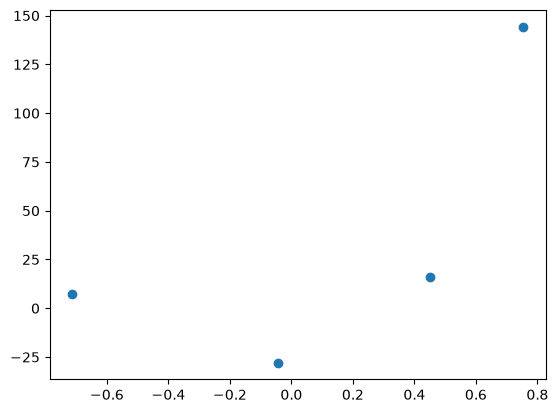

In [5]:
plt.scatter(X,y)

In [6]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [7]:
# m
reg.coef_

array([78.35063668])

In [8]:
reg.intercept_

np.float64(26.15963284313262)

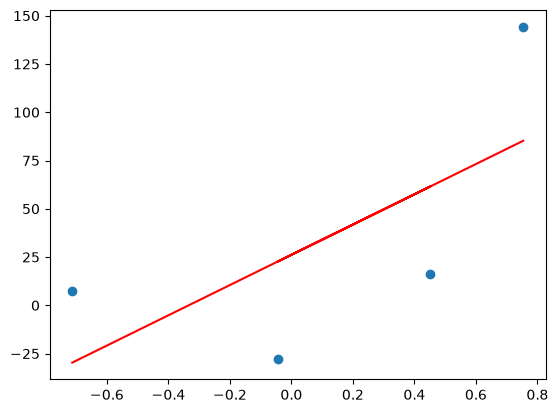

In [ ]:
plt.scatter(X,y)

# it draw the regression line
plt.plot(X,reg.predict(X),color='red')

## Now apply the gradient descent

In [11]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
# line equation - mx + b
#  m is the constant
# m = 87, b-0
y_pred = ((78.35 * X) + 0).reshape(4)

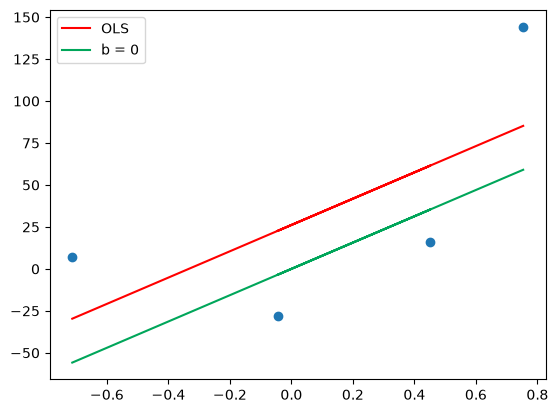

In [ ]:
#  red line  - draw with the help of linear regression
# green line - fraw with gradient descent
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [13]:
# now find out the loss
m = 78.35
b = 0

loss_grad = -2 * np.sum(y - m*X.ravel() - b)
loss_grad


np.float64(-209.27763408209216)

In [14]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_grad*lr
step_size

np.float64(-20.927763408209216)

In [15]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

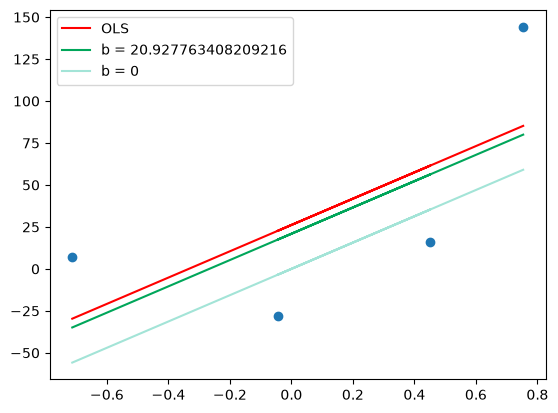

In [16]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [17]:
# Iteration 2
loss_grad = -2 * np.sum(y - m*X.ravel() - b)
loss_grad

np.float64(-41.85552681641843)

In [18]:
step_size = loss_grad*lr
step_size

np.float64(-4.185552681641844)

In [19]:
b = b - step_size
b

np.float64(25.11331608985106)

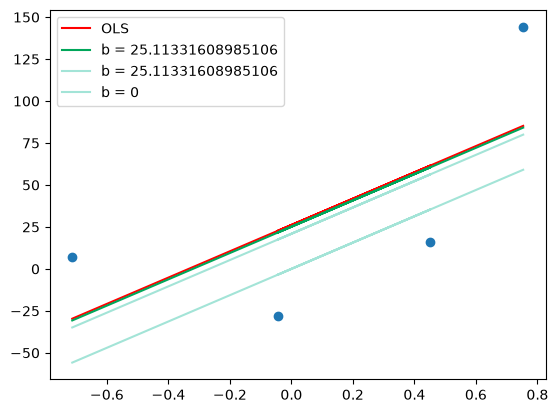

In [20]:
# Iteration 2 result
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

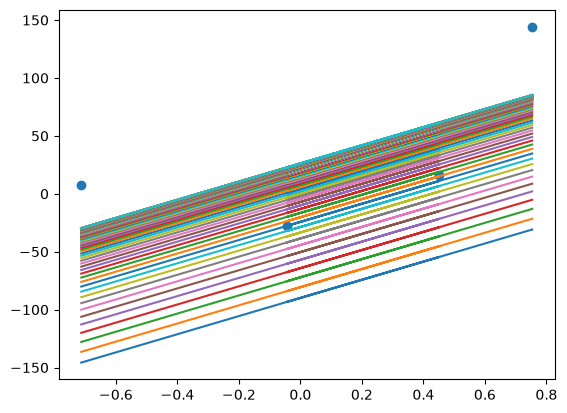

In [21]:
b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_grad = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_grad)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)

In [ ]:
# import pandas as pd
# import numpy as np
# import pandas_datareader.data as web
# from datetime import datetime
# import matplotlib.pyplot as plt

# # Define the stock and time period for data fetching
# stock = 'AAPL'
# start = datetime(2020, 1, 1)
# end = datetime(2022, 1, 1)

# # Fetch the stock data from Yahoo Finance
# stock_data = web.DataReader(stock, 'yahoo', start, end)

# # Prepare data for regression
# # Use adjusted closing prices
# stock_data['Prev Close'] = stock_data['Adj Close'].shift(1)
# stock_data.dropna(inplace=True)  # Remove any rows with NaN values

# # Define the regression target and feature
# X = stock_data['Prev Close'].values.reshape(-1, 1)  # Features
# y = stock_data['Adj Close'].values  # Target

# # Setup for Simple Linear Regression
# # Initialize parameters
# theta_0 = 0  # Intercept
# theta_1 = 0  # Slope
# learning_rate = 0.01
# iterations = 1000

# # Gradient Descent Function
# def gradient_descent(X, y, theta_0, theta_1, learning_rate, iterations):
#     m = len(y)  # Number of data points
#     for _ in range(iterations):
#         prediction = theta_0 + theta_1 * X.flatten()
#         errors = prediction - y
#         theta_0 -= learning_rate * (1/m) * np.sum(errors)
#         theta_1 -= learning_rate * (1/m) * np.sum(errors * X.flatten())
#     return theta_0, theta_1

# # Run gradient descent
# theta_0, theta_1 = gradient_descent(X, y, theta_0, theta_1, learning_rate, iterations)

# # Plotting the results
# plt.figure(figsize=(12, 6))
# plt.scatter(X, y, color='blue', label='Actual Prices', alpha=0.5)
# plt.plot(X, theta_0 + theta_1 * X, color='red', label='Predicted Regression Line')
# plt.title('Simple Linear Regression on AAPL Stock Data')
# plt.xlabel('Previous Day Adjusted Closing Price')
# plt.ylabel('Adjusted Closing Price')
# plt.legend()
# plt.show()